In [1]:
# ! pip install pandas numpy matplotlib scikit-learn scipy cartopy geopy shapely

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from sklearn.linear_model import HuberRegressor
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform
from geopy.distance import geodesic
from geopy import Point
import cartopy.crs as ccrs
from shapely.geometry import LineString, Point as ShapelyPoint, Polygon
from shapely.ops import substring

In [3]:
def load_isc_catalog(file_path):

    # Read all lines from file
    with open(file_path, 'r') as f:
        lines = f.readlines()
    
    # Find data section (skip header and stop at 'STOP')
    start_idx = 21  # Skip first 21 header lines
    end_idx = len(lines)
    
    # Find where data ends (at 'STOP')
    for i in range(start_idx, len(lines)):
        if lines[i].strip().upper() == 'STOP':
            end_idx = i
            break
    
    # Process data lines
    events = []
    magnitudes = []
    
    for i in range(start_idx, end_idx):
        line = lines[i].strip()
        if not line or line.startswith('#'):
            continue
            
        # Remove trailing comma if present
        if line.endswith(','):
            line = line[:-1]
            
        # Split by comma
        parts = [part.strip() for part in line.split(',')]
        
        # Skip malformed lines
        if len(parts) < 9 or not parts[0].replace('.', '').isdigit():
            continue
        
        try:
            # Extract basic event information (first 9 fields)
            event_id = int(parts[0])
            event_type = parts[1].strip()
            author = parts[2].strip()
            date = parts[3].strip()
            time = parts[4].strip()
            
            # Parse coordinates and depth
            lat = float(parts[5]) if parts[5] else np.nan
            lon = float(parts[6]) if parts[6] else np.nan
            depth = float(parts[7]) if parts[7] else np.nan
            depfix = parts[8].strip()
            
            # Add to events list (ONLY basic event data, no magnitudes)
            events.append({
                'EVENTID': event_id,
                'TYPE': event_type,
                'AUTHOR': author,
                'DATE': date,
                'TIME': time,
                'LAT': lat,
                'LON': lon,
                'DEPTH': depth,
                'DEPFIX': depfix
            })
            
            # Process ALL magnitudes starting from position 9 (groups of 3)
            j = 9
            while j + 2 < len(parts):
                mag_author = parts[j].strip()
                mag_type = parts[j+1].strip()
                mag_value = parts[j+2].strip()
                
                # Only add valid magnitude values
                if mag_value and re.match(r'-?\d+(\.\d+)?', mag_value):
                    magnitudes.append({
                        'EVENTID': event_id,
                        'AUTHOR': mag_author,
                        'MAG_TYPE': mag_type,
                        'MAG_VALUE': float(mag_value)
                    })
                
                j += 3
                
        except (ValueError, IndexError) as e:
            print(f"Warning: Error parsing line {i+1}: {e}")
            print(f"Line content: {line[:100]}...")
    
    # Create DataFrames
    main_df = pd.DataFrame(events)
    magnitudes_df = pd.DataFrame(magnitudes) if magnitudes else pd.DataFrame(columns=['EVENTID', 'AUTHOR', 'MAG_TYPE', 'MAG_VALUE'])
    
    print(f"Successfully loaded {len(main_df)} earthquake events")
    if not magnitudes_df.empty:
        print(f"Loaded {len(magnitudes_df)} magnitude measurements from {magnitudes_df['AUTHOR'].nunique()} agencies")
    
    return main_df, magnitudes_df

In [4]:
#Insert here your seismic source parameters [globalcmt.org]
#2010 Maule earthquake
earthquake = {
    'event': '2010 Maule earthquake',
    'latitude': -35.98,
    'longitude': -73.15,
    'depth_km': 23.2,
    'Mw': 8.8,
    'scalar_moment_Nm': 1.86e+29,  # скалярный момент в Н * м
    'strike_deg': 19, # азимут
    'dip_deg': 18, # угол падения
    'rake_deg': 116 # разворот 
}

In [5]:
#Calculating size of rupture using Riznichenko formulae
earthquake['length'] = 10 ** ( 0.440*earthquake['Mw'] -1.289 )
earthquake['width'] = 10 ** ( 0.401*earthquake['Mw'] -1.448 )

print(f"{earthquake['event']} located at ({earthquake['latitude']}°N, {earthquake['longitude']}°E), "
      f"Mw={earthquake['Mw']}, depth={earthquake['depth_km']} km, source length={earthquake['length']} km, source_width={earthquake['width']} km")

2010 Maule earthquake located at (-35.98°N, -73.15°E), Mw=8.8, depth=23.2 km, source length=382.82474331682283 km, source_width=120.44811285731771 km


In [6]:
file_path = 'data/Maule_eqs_reviewed.txt'
main_df, magnitudes_df = load_isc_catalog(file_path)

print("\nMain DataFrame info:")
print(f"Shape: {main_df.shape}")
print("Columns:", list(main_df.columns))
print("\nFirst 5 events:")
print(main_df.head())

if not magnitudes_df.empty:
    print("\nMagnitudes DataFrame info:")
    print(f"Shape: {magnitudes_df.shape}")
    print("Unique magnitude types:", magnitudes_df['MAG_TYPE'].unique())
    print("\nFirst 5 magnitudes:")
    print(magnitudes_df.head())

Successfully loaded 1608 earthquake events
Loaded 12285 magnitude measurements from 9 agencies

Main DataFrame info:
Shape: (1608, 9)
Columns: ['EVENTID', 'TYPE', 'AUTHOR', 'DATE', 'TIME', 'LAT', 'LON', 'DEPTH', 'DEPFIX']

First 5 events:
    EVENTID TYPE AUTHOR        DATE         TIME      LAT      LON  DEPTH  \
0  14340585   se    ISC  2010-02-27  06:34:12.60 -36.2714 -72.9113   22.9   
1  17149171   ke    ISC  2010-02-27  06:50:38.33 -37.1935 -73.0555   50.0   
2  16114035   se    ISC  2010-02-27  06:52:31.52 -34.8485 -72.7380   18.0   
3  17149177   ke    IDC  2010-02-27  06:57:17.04 -35.0791 -72.5808    0.0   
4  17149179   se    ISC  2010-02-27  07:02:02.65 -38.1010 -73.6502   22.0   

  DEPFIX  
0         
1   TRUE  
2   TRUE  
3   TRUE  
4   TRUE  

Magnitudes DataFrame info:
Shape: (12285, 4)
Unique magnitude types: ['mb' 'MS' 'mb1' 'mb1mx' 'mbtmp' 'ML' 'Ms1' 'ms1mx' 'ME' 'MW' 'mB' 'Ms'
 'Ms7' 'MD']

First 5 magnitudes:
    EVENTID AUTHOR MAG_TYPE  MAG_VALUE
0  14340585    IS

In [7]:
neic_magnitudes = magnitudes_df[magnitudes_df['AUTHOR'] == 'NEIC'].copy()

neic_magnitudes = neic_magnitudes.groupby('EVENTID').first().reset_index()

merged_df = pd.merge(main_df, neic_magnitudes, on='EVENTID', how='inner')

final_df = merged_df[['LAT', 'LON', 'DEPTH', 'MAG_VALUE']].rename(columns={
    'LAT': 'latitude',
    'LON': 'longitude',
    'DEPTH': 'depth',
    'MAG_VALUE': 'mag'
})

# Определение минимальной глубины для зоны субдукции
min_subduction_depth = 10

final_df = final_df[final_df['depth'] >= min_subduction_depth]

#Filter initial seismic catalog to get earthquakes with magnitudes exceed threshold
mag_threshold = 4.5
final_df = final_df[final_df['mag'] > mag_threshold]

#Cleaning data from NaNs
final_df_clean = final_df.dropna().reset_index(drop=True)

# Display first few rows of the cleaned dataframe
final_df_clean.head()

,latitude,longitude,depth,mag
0,-36.2714,-72.9113,22.9,7.2
1,-34.8485,-72.7380,18.0,6.2
2,-38.1010,-73.6502,22.0,5.1
3,-36.9372,-73.4116,14.0,5.2
4,-36.0697,-72.7942,35.0,5.4


In [8]:
#Reading lithospheric plate bounadries for NNR-MORVEL56 model [Argus et al., 2011]
file_path = 'data/All_boundaries'

latitudes = []
longitudes = []

with open(file_path, 'r') as file:
    for line in file:
        if not line.startswith(' '):
            continue  # skip comment lines without leading spaces
        try:
            parts = line.strip().split()
            if len(parts) != 2:
                print(f"Skipping malformed line: {line.strip()}")
                continue
            lat, lon = map(float, parts)
            latitudes.append(lat)
            longitudes.append(lon)
        except Exception as e:
            print(f"Error parsing line '{line.strip()}': {e}")

# Create DataFrame
boundaries_df = pd.DataFrame({
    'latitude': latitudes,
    'longitude': longitudes
})

print(boundaries_df.head())

   latitude  longitude
0   -54.852     -0.438
1   -54.677     -0.039
2   -54.451      0.443
3   -54.832      0.965
4   -54.399      1.695


In [9]:
#Calculating geographic area for catalog search
#Making boundary points in strike direction

# Half-length distance
half_length = earthquake['length'] / 2  # in km

# Starting point (epicenter)
epicenter = Point(earthquake['latitude'], earthquake['longitude'])

# Point in strike direction
point_forward = geodesic(kilometers=half_length).destination(epicenter, earthquake['strike_deg'])

# Point in opposite strike direction (+180°)
point_backward = geodesic(kilometers=half_length).destination(epicenter, (earthquake['strike_deg'] + 180) % 360)

print(f"Point forward (along strike): lat={point_forward.latitude}, lon={point_forward.longitude}")
print(f"Point backward (opposite strike): lat={point_backward.latitude}, lon={point_backward.longitude}")

Point forward (along strike): lat=-34.346760194973996, lon=-72.47277567017099
Point backward (opposite strike): lat=-37.60881253553208, lon=-73.85568651113753


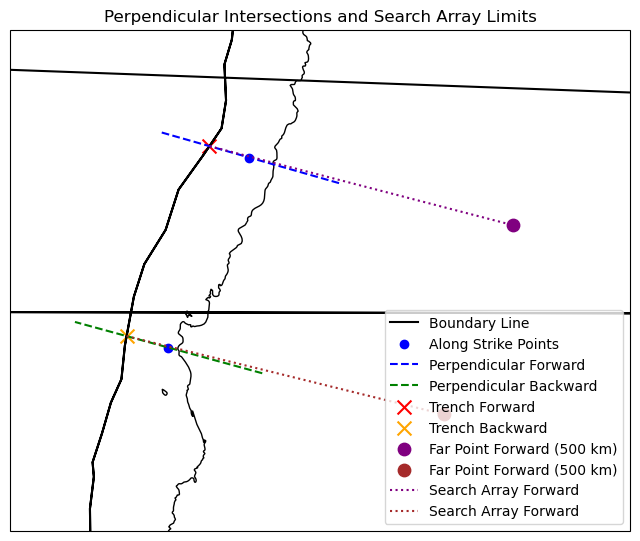

In [10]:
#Finding closest boundary(trench) and calculating intersect points

# Step 1: Boundary line from DataFrame
line = LineString(zip(boundaries_df['longitude'], boundaries_df['latitude']))

# -------- Perpendicular Line Construction ---------
def build_perpendicular_line(start_point, strike, length=150):
    az1 = (strike + 90) % 360
    az2 = (strike - 90) % 360
    p1 = geodesic(kilometers=length).destination(start_point, az1)
    p2 = geodesic(kilometers=length).destination(start_point, az2)
    return LineString([(p1.longitude, p1.latitude), (p2.longitude, p2.latitude)])

perp_line_forward = build_perpendicular_line(point_forward, earthquake['strike_deg'])
perp_line_backward = build_perpendicular_line(point_backward, earthquake['strike_deg'])

# -------- Intersection with boundary ---------
def project_intersection(perp_line, boundary_line):
    intersection = perp_line.intersection(boundary_line)
    if intersection.is_empty:
        return None, None
    if intersection.geom_type == 'Point':
        return intersection.y, intersection.x
    elif intersection.geom_type == 'MultiPoint':
        point = list(intersection)[0]
        return point.y, point.x
    else:
        return None, None

p1_lat, p1_lon = project_intersection(perp_line_forward, line)
p2_lat, p2_lon = project_intersection(perp_line_backward, line)

# Create Shapely Points for p1 and p2
p1_geom = ShapelyPoint(p1_lon, p1_lat)
p2_geom = ShapelyPoint(p2_lon, p2_lat)

# Project points onto the boundary line (returns distance along the line)
distance_p1 = line.project(p1_geom)
distance_p2 = line.project(p2_geom)

# Ensure proper order (from p1 to p2 along the boundary line)
start_distance = min(distance_p1, distance_p2)
end_distance = max(distance_p1, distance_p2)

# Extract the subsection of the boundary line (which is closest to the source)
sub_boundary = substring(line, start_distance, end_distance)

# Optional: Extract lat/lon coordinates
sub_lon, sub_lat = sub_boundary.xy

# -------- Compute far points 500 km from intersection ---------
def point_along_direction(lat, lon, azimuth, distance_km):
    start = Point(lat, lon)
    dest = geodesic(kilometers=distance_km).destination(start, azimuth)
    return dest.latitude, dest.longitude

def calculate_far_point(inter_lat, inter_lon, strike, direction): # strike не используется!!!
    azimuth = (strike + 90) % 360 if direction == 'forward' else (strike - 90) % 360 # исправлено
    far_lat, far_lon = point_along_direction(inter_lat, inter_lon, azimuth, 500)
    return far_lat, far_lon

far1_lat, far1_lon = calculate_far_point(p1_lat, p1_lon, earthquake['strike_deg'], 'forward')
far2_lat, far2_lon = calculate_far_point(p2_lat, p2_lon, earthquake['strike_deg'], 'forward')

# -------- Plotting ---------
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={'projection': ccrs.PlateCarree()})
ax.coastlines(resolution='10m')

# Boundary line
ax.plot(boundaries_df['longitude'], boundaries_df['latitude'], color='black', label='Boundary Line')

# Along-strike points
ax.scatter([point_forward.longitude, point_backward.longitude],
           [point_forward.latitude, point_backward.latitude], color='blue', label='Along Strike Points')

# Perpendicular lines
x_perp1, y_perp1 = perp_line_forward.xy
x_perp2, y_perp2 = perp_line_backward.xy
ax.plot(x_perp1, y_perp1, 'b--', label='Perpendicular Forward')
ax.plot(x_perp2, y_perp2, 'g--', label='Perpendicular Backward')

# Intersection points
ax.scatter(p1_lon, p1_lat, color='red', marker='x', s=100, label='Trench Forward')
ax.scatter(p2_lon, p2_lat, color='orange', marker='x', s=100, label='Trench Backward')

# Far points 500 km away
ax.scatter(far1_lon, far1_lat, color='purple', marker='o', s=80, label='Far Point Forward (500 km)')
ax.scatter(far2_lon, far2_lat, color='brown', marker='o', s=80, label='Far Point Forward (500 km)')

# Lines to far points
ax.plot([p1_lon, far1_lon], [p1_lat, far1_lat], 'purple', linestyle=':', label='Search Array Forward')
ax.plot([p2_lon, far2_lon], [p2_lat, far2_lat], 'brown', linestyle=':', label='Search Array Forward')

# Zoom to region
all_lats = [point_forward.latitude, point_backward.latitude, p1_lat, p2_lat, far1_lat, far2_lat]
all_lons = [point_forward.longitude, point_backward.longitude, p1_lon, p2_lon, far1_lon, far2_lon]
margin_lat, margin_lon = 2, 2
ax.set_extent([
    np.nanmin(all_lons) - margin_lon, np.nanmax(all_lons) + margin_lon,
    np.nanmin(all_lats) - margin_lat, np.nanmax(all_lats) + margin_lat
], crs=ccrs.PlateCarree())

ax.legend(loc='lower right')
ax.set_title('Perpendicular Intersections and Search Array Limits')
plt.show;

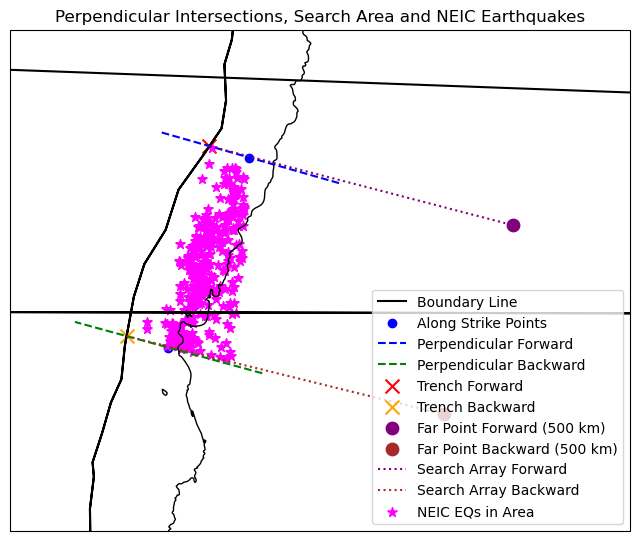

In [11]:
# -------- Define polygon for earthquake catalog search---------
search_polygon = Polygon([
    (p1_lon, p1_lat),
    (far1_lon, far1_lat),
    (far2_lon, far2_lat),
    (p2_lon, p2_lat),
    (p1_lon, p1_lat)
])

# Filter earthquakes inside the search polygon
def is_inside(lat, lon):
    return search_polygon.contains(ShapelyPoint(lon, lat))

final_df['inside_polygon'] = final_df.apply(lambda row: is_inside(row['latitude'], row['longitude']), axis=1)
selected_eq = final_df[final_df['inside_polygon']]

# -------- Plotting ---------
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={'projection': ccrs.PlateCarree()})
ax.coastlines(resolution='10m')

# Boundary line
ax.plot(boundaries_df['longitude'], boundaries_df['latitude'], color='black', label='Boundary Line')

# Along-strike points
ax.scatter([point_forward.longitude, point_backward.longitude],
           [point_forward.latitude, point_backward.latitude], color='blue', label='Along Strike Points')

# Perpendicular lines
x_perp1, y_perp1 = perp_line_forward.xy
x_perp2, y_perp2 = perp_line_backward.xy
ax.plot(x_perp1, y_perp1, 'b--', label='Perpendicular Forward')
ax.plot(x_perp2, y_perp2, 'g--', label='Perpendicular Backward')

# Intersection points
ax.scatter(p1_lon, p1_lat, color='red', marker='x', s=100, label='Trench Forward')
ax.scatter(p2_lon, p2_lat, color='orange', marker='x', s=100, label='Trench Backward')

# Far points 500 km away
ax.scatter(far1_lon, far1_lat, color='purple', marker='o', s=80, label='Far Point Forward (500 km)')
ax.scatter(far2_lon, far2_lat, color='brown', marker='o', s=80, label='Far Point Backward (500 km)')

# Lines to far points
ax.plot([p1_lon, far1_lon], [p1_lat, far1_lat], 'purple', linestyle=':', label='Search Array Forward')
ax.plot([p2_lon, far2_lon], [p2_lat, far2_lat], 'brown', linestyle=':', label='Search Array Backward')

# Earthquakes inside polygon
ax.scatter(selected_eq['longitude'], selected_eq['latitude'], color='magenta', marker='*', s=50, label='NEIC EQs in Area')

# Zoom to region
all_lats = [point_forward.latitude, point_backward.latitude, p1_lat, p2_lat, far1_lat, far2_lat]
all_lons = [point_forward.longitude, point_backward.longitude, p1_lon, p2_lon, far1_lon, far2_lon]
margin_lat, margin_lon = 2, 2
ax.set_extent([
    np.nanmin(all_lons) - margin_lon, np.nanmax(all_lons) + margin_lon,
    np.nanmin(all_lats) - margin_lat, np.nanmax(all_lats) + margin_lat
], crs=ccrs.PlateCarree())

ax.legend(loc='lower right')
ax.set_title('Perpendicular Intersections, Search Area and NEIC Earthquakes')
plt.show()

In [12]:
# -------- Distance to Boundary Calculation ---------
def distance_to_boundary(lat, lon, boundary_line):
    point_geom = ShapelyPoint(lon, lat)
    nearest_point = boundary_line.interpolate(boundary_line.project(point_geom))
    distance = geodesic((lat, lon), (nearest_point.y, nearest_point.x)).km
    return distance

# DataFrame with depth and distance from boundary
depth_distance_df = selected_eq.copy()
depth_distance_df['depth'] = -np.abs(depth_distance_df['depth'])
depth_distance_df['distance'] = depth_distance_df.apply(
    lambda row: distance_to_boundary(row['latitude'], row['longitude'], sub_boundary), axis=1
)
depth_distance_df = depth_distance_df[['depth', 'distance']]
depth_distance_df.reset_index(drop=True, inplace=True)
depth_distance_df.head(20)

,depth,distance
0,-22.9,80.410399
1,-18.0,72.837415
2,-14.0,6.421149
3,-35.0,102.816092
4,-19.6,4.321687
5,-22.9,82.763208
6,-28.0,90.891797
7,-10.0,83.308328
8,-33.4,9.842132
9,-27.9,13.839496


In [13]:
depth_distance_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 326 entries, 0 to 325
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   depth     326 non-null    float64
 1   distance  326 non-null    float64
dtypes: float64(2)
memory usage: 5.2 KB


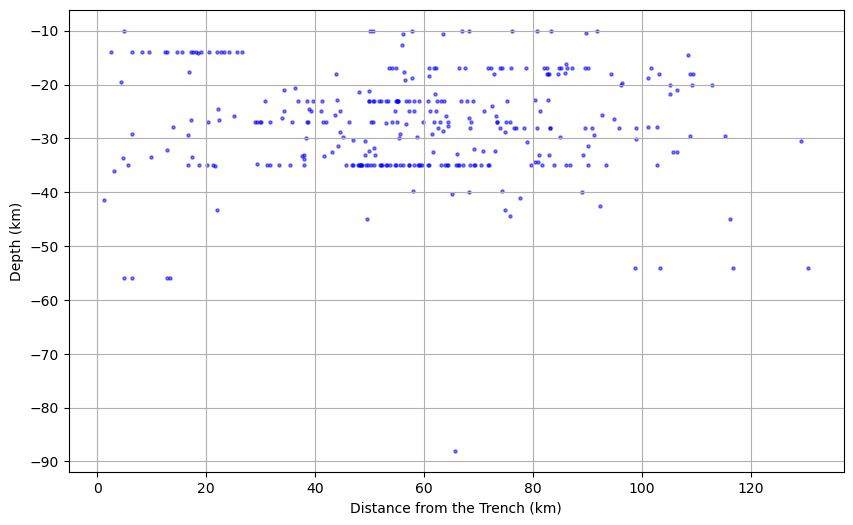

In [14]:
plt.figure(figsize=(10, 6))
plt.scatter(depth_distance_df.distance, depth_distance_df.depth, color='blue', s=5, alpha=0.5)
plt.xlabel('Distance from the Trench (km)')
plt.ylabel('Depth (km)')
plt.grid(True)
plt.show()

In [15]:
depth_frequency = depth_distance_df['depth'].value_counts()

frequent_depths = depth_frequency[depth_frequency > 8]

print("Earthquake depths repeating more than 50 times:")
print("------------------------------------------------")
for depth, count in frequent_depths.items():
    print(f"Depth {depth:6.2f} km: {count:3d} repetitions")

Earthquake depths repeating more than 50 times:
------------------------------------------------
Depth -35.00 km:  64 repetitions
Depth -23.00 km:  29 repetitions
Depth -27.00 km:  24 repetitions
Depth -17.00 km:  23 repetitions
Depth -14.00 km:  19 repetitions
Depth -28.00 km:  13 repetitions
Depth -10.00 km:  10 repetitions
Depth -18.00 km:  10 repetitions
Depth -25.00 km:  10 repetitions


Removed 0 crustal earthquakes initially


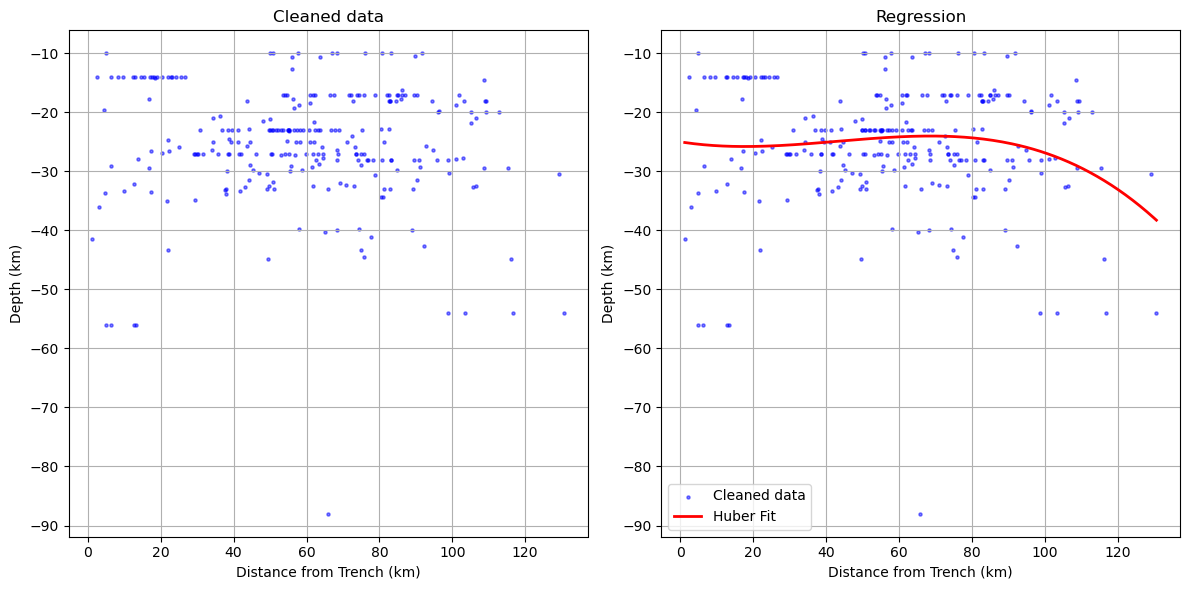

In [16]:
# 1. Clean data
depth_distance_df_cleaned = depth_distance_df.query("depth != -35").copy()
X_raw = depth_distance_df_cleaned['distance'].values.reshape(-1, 1)
y_raw = depth_distance_df_cleaned['depth'].values

# 2. Pre-filtering of crustal earthquakes
def filter_crustal_earthquakes(distance, depth, max_shallow_depth, min_distance_for_filter):
    return ~((depth > max_shallow_depth) & (distance > min_distance_for_filter))

crustal_mask = filter_crustal_earthquakes(X_raw.flatten(), y_raw, max_shallow_depth=0, min_distance_for_filter=0)
X_filtered = X_raw[crustal_mask]
y_filtered = y_raw[crustal_mask]

print(f"Removed {len(X_raw) - len(X_filtered)} crustal earthquakes initially")

# 3. Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_filtered)
mu_X, sigma_X = scaler.mean_[0], scaler.scale_[0]
y_mean, y_std = y_filtered.mean(), y_filtered.std()
y_scaled = (y_filtered - y_mean) / y_std

# 4. Polynomial transform
degree = 3
poly = PolynomialFeatures(degree=degree, include_bias=False)
X_poly = poly.fit_transform(X_scaled)

# 5. Huber regression
param_grid = {'epsilon': uniform(1, 2), 'alpha': uniform(0.0001, 0.01), 'max_iter': [100, 300, 500]}
search = RandomizedSearchCV(HuberRegressor(), param_grid, n_iter=20, cv=5, random_state=42)
search.fit(X_poly, y_scaled)

model = HuberRegressor(**search.best_params_)
model.fit(X_poly, y_scaled)

# 6. Predict on smooth linspace
X_fit = np.linspace(X_filtered.min(), X_filtered.max(), 200).reshape(-1, 1)
X_fit_scaled = (X_fit - mu_X) / sigma_X
X_fit_poly = poly.transform(X_fit_scaled)
y_fit_scaled = model.predict(X_fit_poly)
y_fit = y_fit_scaled * y_std + y_mean


# 9. Plot comparison
plt.figure(figsize=(12, 6))

# Сleaned data
plt.subplot(1, 2, 1)
plt.scatter(X_raw, y_raw, color='blue', s=5, alpha=0.5)
plt.title('Сleaned data')
plt.xlabel('Distance from Trench (km)')
plt.ylabel('Depth (km)')
plt.grid(True)

# Regression
plt.subplot(1, 2, 2)
plt.scatter(X_filtered, y_filtered, color='blue', s=5, alpha=0.5, label='Сleaned data')
plt.plot(X_fit, y_fit, color='red', linewidth=2, label='Huber Fit')
plt.title('Regression')
plt.xlabel('Distance from Trench (km)')
plt.ylabel('Depth (km)')
plt.grid(True)
plt.legend(loc='lower left')

plt.tight_layout()
plt.show()

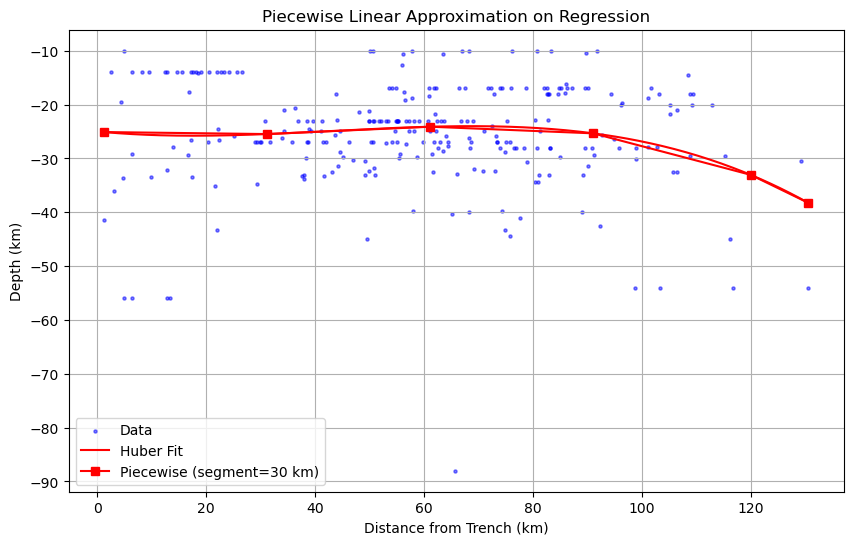

Angles between segments (degrees):
Segment 1: -0.71°
Segment 2: 2.61°
Segment 3: -2.35°
Segment 4: -14.92°
Segment 5: -26.17°


In [17]:
# 1. Prepare smooth curve from regression
X_fit = np.linspace(X_filtered.min(), X_filtered.max(), 300).reshape(-1, 1)
X_fit_scaled = (X_fit - mu_X) / sigma_X
X_fit_poly = poly.transform(X_fit_scaled)
y_fit_scaled = model.predict(X_fit_poly)
y_fit = y_fit_scaled * y_std + y_mean

# 2. Piecewise approximation works on X_fit and y_fit in original scale
X_appr = X_fit.flatten()
y_appr = y_fit.flatten()

# 3. Euclidean distance in (X, Y) plane
def euclidean_distance(p1, p2):
    return np.linalg.norm(p1 - p2)

# 4. Piecewise approximation function
def piecewise_approximation(X_appr, y_appr, segment_length):
    nodes = [(X_appr[0], y_appr[0])]
    total_distance = 0.0
    current_node = np.array(nodes[0])

    for i in range(1, len(X_appr)):
        next_point = np.array([X_appr[i], y_appr[i]])
        dist = euclidean_distance(current_node, next_point)

        while total_distance + dist >= segment_length:
            ratio = (segment_length - total_distance) / dist
            new_node = current_node + ratio * (next_point - current_node)
            nodes.append(tuple(new_node))
            current_node = new_node
            total_distance = 0.0
            dist = euclidean_distance(current_node, next_point)

        total_distance += dist
        current_node = next_point

    nodes.append((X_appr[-1], y_appr[-1]))

    hx, hy = zip(*nodes)
    angles = [np.arctan2(hy[i+1] - hy[i], hx[i+1] - hx[i]) for i in range(len(hx)-1)]
    return hx, hy, angles

# 5. Apply piecewise approximation
segment_length = 30  # km
hx, hy, angles = piecewise_approximation(X_appr, y_appr, segment_length)

# 6. Plot
plt.figure(figsize=(10, 6))
plt.scatter(X_filtered, y_filtered, color='blue', label='Data', s=5, alpha=0.5)
plt.plot(X_fit, y_fit, color='red', label='Huber Fit')
plt.plot(hx, hy, 'rs-', label=f'Piecewise (segment={segment_length} km)')
plt.xlabel('Distance from Trench (km)')
plt.ylabel('Depth (km)')
plt.title('Piecewise Linear Approximation on Regression')
plt.legend(loc='lower left')
plt.grid()
plt.show()

# 7. Print angles
print("Angles between segments (degrees):")
for idx, angle in enumerate(angles):
    print(f"Segment {idx+1}: {np.degrees(angle):.2f}°")

Лучшие параметры: {'alpha': np.float64(0.004967421529594552), 'epsilon': np.float64(2.812197575437108), 'max_iter': 300}


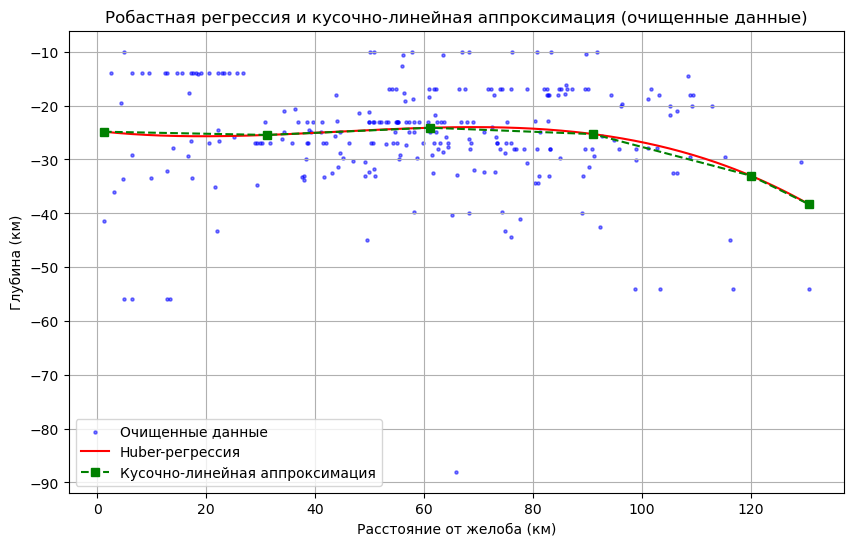

Углы сегментов (в градусах):
Сегмент 1: -1.15°
Сегмент 2: 2.56°
Сегмент 3: -2.26°
Сегмент 4: -14.94°
Сегмент 5: -26.36°


In [18]:
# 4. Полиномиальные признаки
degree = 3
poly = PolynomialFeatures(degree=degree, include_bias=False)
X_poly = poly.fit_transform(X_scaled)

# 5. Обучение робастной регрессии с подбором параметров
param_distributions_huber = {'epsilon': uniform(1.0, 2.0), 'alpha': uniform(0.0001, 0.01), 'max_iter': [100, 200, 300, 400, 500]}
huber = HuberRegressor()
search = RandomizedSearchCV(huber, param_distributions_huber, n_iter=100, cv=5, random_state=42)
search.fit(X_poly, y_scaled)

huber_best = HuberRegressor(**search.best_params_)
huber_best.fit(X_poly, y_scaled)

print("Лучшие параметры:", search.best_params_)

# 6. Предсказания на сглаженном ряду
X_fit = np.linspace(X_filtered.min(), X_filtered.max(), 300).reshape(-1, 1)
X_fit_scaled = (X_fit - mu_X) / sigma_X
X_fit_poly = poly.transform(X_fit_scaled)
y_fit_scaled = huber_best.predict(X_fit_poly)
y_fit = y_fit_scaled * y_std + y_mean

# 7. Кусочно-линейная аппроксимация по предсказанной кривой

segment_length = 30
hx, hy, angles = piecewise_approximation(X_fit.flatten(), y_fit.flatten(), segment_length)

# 8. График модели и кусочно-линейной аппроксимации
plt.figure(figsize=(10, 6))
plt.scatter(X_filtered, y_filtered, color='blue', label='Очищенные данные', s=5, alpha=0.5)
plt.plot(X_fit, y_fit, color='red', label='Huber-регрессия')
plt.plot(hx, hy, 'gs--', label='Кусочно-линейная аппроксимация')
plt.title('Робастная регрессия и кусочно-линейная аппроксимация (очищенные данные)')
plt.xlabel('Расстояние от желоба (км)')
plt.ylabel('Глубина (км)')
plt.legend()
plt.grid()
plt.show()

# 9. Печать углов сегментов
print("Углы сегментов (в градусах):")
for idx, angle in enumerate(angles):
    print(f"Сегмент {idx+1}: {np.degrees(angle):.2f}°")